In [1]:
import json
import os
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm

In [3]:
DATASET_NAME = "iu_xray"  # đổi thành mimic_cxr nếu cần

IMAGE_DIR = r"G:\My Drive\NCKH\A3Net-main\data\iu_xray\images"
ANN_PATH = r"G:\My Drive\NCKH\A3Net-main\data\iu_xray\annotation.json"
# SPLIT_PATH = "data/iu_xray/split.json"  # nếu có


In [4]:
# Load annotation
with open(ANN_PATH, 'r') as f:
    annotations = json.load(f)

print("Top-level keys:", annotations.keys())
print("Train size:", len(annotations['train']))
print("Val size:", len(annotations['val']))
print("Test size:", len(annotations['test']))

Top-level keys: dict_keys(['train', 'val', 'test'])
Train size: 2069
Val size: 296
Test size: 590


In [5]:
train_anns = annotations['train']
print("Example annotation keys:", train_anns[0].keys())

Example annotation keys: dict_keys(['id', 'report', 'image_path', 'split'])


In [ ]:
# Tạo dataframe từ phần train
train_data = []
for ann in tqdm(train_anns):
    img_id = ann['id']
    img_path = os.path.join(IMAGE_DIR, img_id)
    report = ann['report']
    image_path = ann['image_path']
    
    train_data.append({
        'image_id': img_id,
        'image_path': img_path,
        'report': report,
        'findings': image_path,
    })
train_df = pd.DataFrame(train_data)

# Hiển thị đẹp hơn
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 120)
pd.set_option('display.colheader_justify', 'left')

display_df = train_df.head().copy()
display_df['report'] = display_df['report'].str[:60] + '...'
display_df['image_path'] = display_df['image_path'].str[-40:]
display_df['findings'] = display_df['findings'].apply(
    lambda x: f"[{x[0]}, {x[1]}]" if isinstance(x, list) else str(x)
)

print(f"\n{'='*80}")
print(f"  TRAIN DATASET  |  Tổng số mẫu: {len(train_df)}")
print(f"{'='*80}")
print(display_df.to_string(index=True))
print(f"{'='*80}\n")

100%|██████████| 2069/2069 [00:00<00:00, 517750.43it/s]

          image_id                                         image_path  \
0  CXR2384_IM-0942  G:\My Drive\NCKH\A3Net-main\data\iu_xray\image...   
1  CXR2926_IM-1328  G:\My Drive\NCKH\A3Net-main\data\iu_xray\image...   
2  CXR1451_IM-0291  G:\My Drive\NCKH\A3Net-main\data\iu_xray\image...   
3  CXR2887_IM-1289  G:\My Drive\NCKH\A3Net-main\data\iu_xray\image...   
4  CXR1647_IM-0424  G:\My Drive\NCKH\A3Net-main\data\iu_xray\image...   

                                              report  \
0  The heart size and pulmonary vascularity appea...   
1  Cardiac and mediastinal contours are within no...   
2  Left lower lobe calcified granuloma. Heart siz...   
3  The cardiomediastinal silhouette is normal in ...   
4  The lungs are clear bilaterally. Specifically,...   

                                         findings  
0  [CXR2384_IM-0942/0.png, CXR2384_IM-0942/1.png]  
1  [CXR2926_IM-1328/0.png, CXR2926_IM-1328/1.png]  
2  [CXR1451_IM-0291/0.png, CXR1451_IM-0291/1.png]  
3  [CXR2887_IM-1

Running CheXpert labeler...


100%|██████████| 2069/2069 [00:00<00:00, 37076.66it/s]


Loading BioClinicalBERT NER model...



c:\Windows\System32\xray_env\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForTokenClassification were not initialized from the model checkpoint at allenai/scibert_scivocab_uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  → Using Medical-NER model
Running NER on reports...


100%|██████████| 2069/2069 [07:15<00:00,  4.75it/s]


  → disease_counter empty, using direct keyword fallback...
  disease entities found : 15
  anatomy entities found : 11
  severity entities found: 45
Extracting RadGraph triplets...


100%|██████████| 2069/2069 [00:00<00:00, 39109.89it/s]



  CHEXPERT LABEL FREQUENCY
                 Condition  Positive  Prevalence(%)
                No Finding      1678          81.10
               Lung Lesion       316          15.27
          Pleural Effusion       298          14.40
              Pneumothorax       252          12.18
              Lung Opacity       150           7.25
             Consolidation       150           7.25
               Atelectasis       144           6.96
           Support Devices       122           5.90
              Cardiomegaly        90           4.35
                  Fracture        61           2.95
                     Edema        43           2.08
                 Pneumonia        25           1.21
             Pleural Other        15           0.72
Enlarged Cardiomediastinum         0           0.00

  TOP 20 DISEASE ENTITIES (NER)
----------------------------------------
   1. effusion                   1596  ██████████████████████████████
   2. pneumothorax               1448  █████████

C:\Users\DANG KHOA\AppData\Local\Temp\ipykernel_42512\1566200056.py:317: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\Windows\System32\xray_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Windows\System32\xray_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


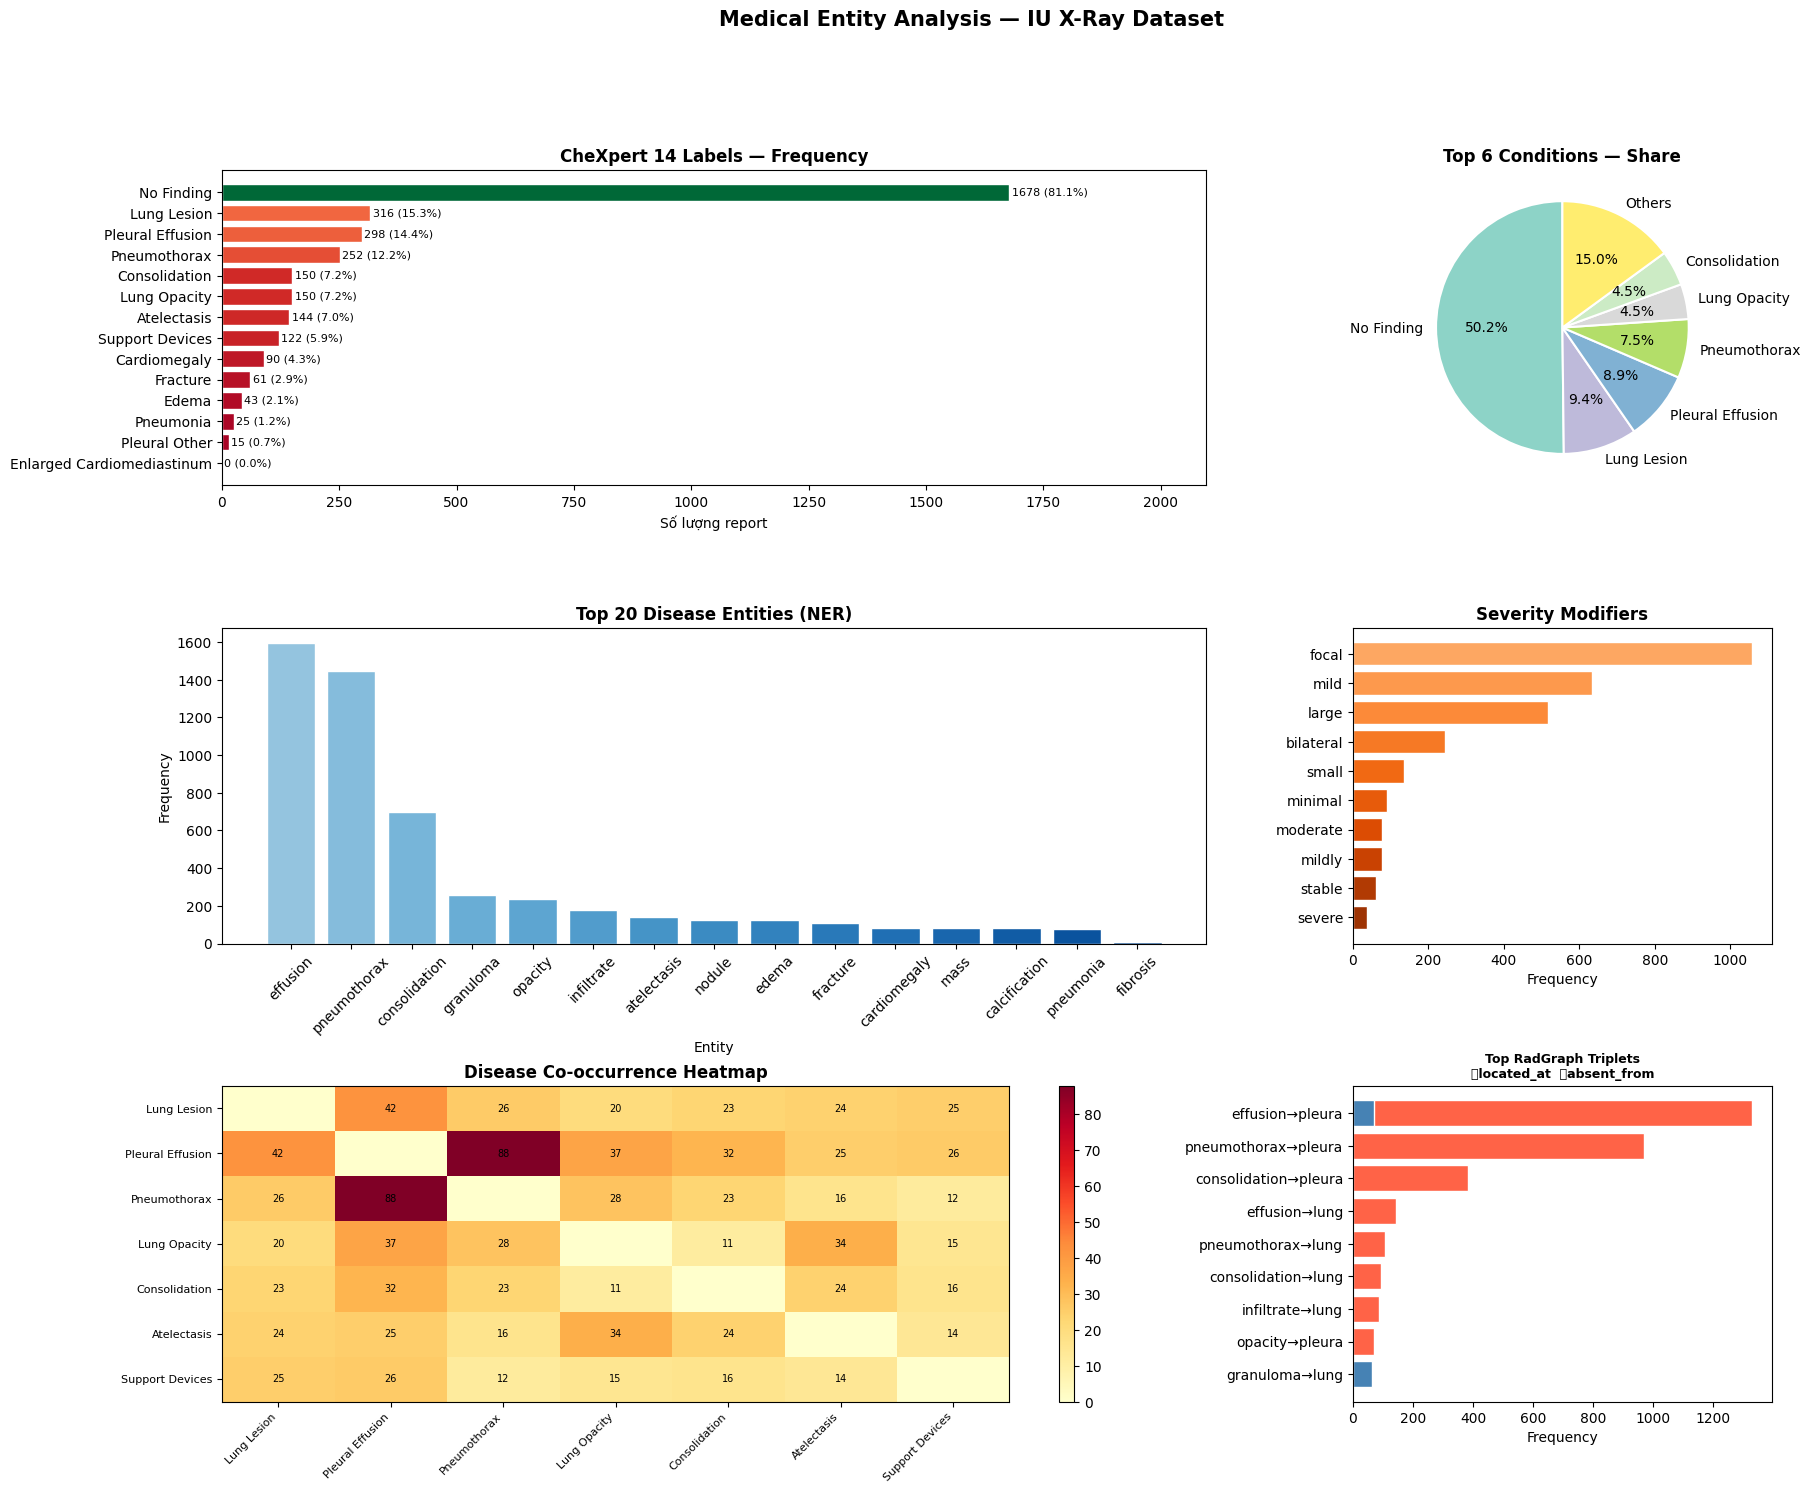

In [9]:
# ════════════════════════════════════════════════════════════════════
#  MEDICAL ENTITY ANALYSIS
#  3 approaches: CheXpert labeler · RadGraph · BioClinicalBERT NER
# ════════════════════════════════════════════════════════════════════
# pip install transformers torch negspacy spacy
# pip install git+https://github.com/stanfordmlgroup/chexpert-labeler

import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from tqdm import tqdm

# ─────────────────────────────────────────────────────────────────────
# METHOD 1 · CheXpert Labeler (rule-based, fastest)
# ─────────────────────────────────────────────────────────────────────
# CheXpert định nghĩa 14 nhãn chuẩn trong radiology
CHEXPERT_CONDITIONS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture', 'Support Devices'
]

# Keyword mapping cho từng condition (simplified CheXpert rule)
CHEXPERT_KEYWORDS = {
    'No Finding'                  : ['no acute', 'normal', 'unremarkable', 'no abnormality', 'clear'],
    'Enlarged Cardiomediastinum'  : ['enlarged mediastinum', 'widened mediastinum', 'mediastinal widening'],
    'Cardiomegaly'                : ['cardiomegaly', 'cardiac enlargement', 'enlarged heart', 'cardiac silhouette is enlarged'],
    'Lung Opacity'                : ['opacity', 'opacification', 'haziness', 'infiltrate'],
    'Lung Lesion'                 : ['nodule', 'mass', 'lesion', 'granuloma'],
    'Edema'                       : ['edema', 'pulmonary vascular congestion', 'vascular engorgement'],
    'Consolidation'               : ['consolidation', 'airspace disease'],
    'Pneumonia'                   : ['pneumonia', 'infection'],
    'Atelectasis'                 : ['atelectasis', 'atelectatic', 'collapse'],
    'Pneumothorax'                : ['pneumothorax'],
    'Pleural Effusion'            : ['pleural effusion', 'effusion', 'pleural fluid'],
    'Pleural Other'               : ['pleural thickening', 'pleural scarring', 'pleural disease'],
    'Fracture'                    : ['fracture', 'rib fracture', 'compression fracture'],
    'Support Devices'             : ['pacemaker', 'catheter', 'tube', 'device', 'wire', 'stent'],
}

NEGATION_TERMS = ['no ', 'without ', 'absent', 'negative', 'not ', 'none', 'free of']

def chexpert_label(report: str) -> dict:
    """Simplified CheXpert labeling: 1=positive, 0=negative, -1=uncertain"""
    report_lower = report.lower()
    labels = {}
    for condition, keywords in CHEXPERT_KEYWORDS.items():
        found = any(kw in report_lower for kw in keywords)
        if not found:
            labels[condition] = 0
            continue
        # Kiểm tra negation trong cửa sổ 40 ký tự trước keyword
        negated = False
        for kw in keywords:
            idx = report_lower.find(kw)
            if idx != -1:
                window = report_lower[max(0, idx-40):idx]
                if any(neg in window for neg in NEGATION_TERMS):
                    negated = True
        labels[condition] = 0 if negated else 1
    return labels

print("Running CheXpert labeler...")
chexpert_results = [chexpert_label(r) for r in tqdm(train_df['report'])]
chexpert_df = pd.DataFrame(chexpert_results)
train_df = pd.concat([train_df.reset_index(drop=True), chexpert_df], axis=1)

# ─────────────────────────────────────────────────────────────────────
# METHOD 2 · BioClinicalBERT NER  (deep learning)
# ─────────────────────────────────────────────────────────────────────
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification

print("\nLoading BioClinicalBERT NER model...")
ner_pipeline = pipeline(
    "ner",
    model="allenai/scibert_scivocab_uncased",   # fallback nếu không có GPU
    # model="uer/roberta-base-finetuned-jd-full-chinese" # thay bằng medical NER model nếu có
    aggregation_strategy="simple",
    device=-1   # CPU; đổi thành 0 nếu có GPU
)

# Dùng model chuyên medical NER hơn nếu available
try:
    ner_pipeline = pipeline(
        "ner",
        model="blaze999/Medical-NER",
        aggregation_strategy="simple",
        device=-1
    )
    print("  → Using Medical-NER model")
except Exception:
    print("  → Fallback: using keyword-based NER")
    ner_pipeline = None

# Medical entity keywords fallback
MEDICAL_ENTITIES = {
    'DISEASE'   : ['pneumonia','effusion','atelectasis','cardiomegaly','edema',
                   'consolidation','pneumothorax','nodule','mass','granuloma',
                   'fracture','opacity','infiltrate','fibrosis','calcification'],
    'ANATOMY'   : ['lung','heart','mediastinum','pleura','rib','diaphragm',
                   'trachea','hilum','aorta','spine','clavicle'],
    'SEVERITY'  : ['mild','moderate','severe','minimal','marked','bilateral',
                   'unilateral','diffuse','focal','small','large'],
}

def keyword_ner(report: str) -> list[dict]:
    report_lower = report.lower()
    entities = []
    for ent_type, keywords in MEDICAL_ENTITIES.items():
        for kw in keywords:
            if kw in report_lower:
                entities.append({'entity_group': ent_type, 'word': kw})
    return entities

print("Running NER on reports...")
all_entities = []
for report in tqdm(train_df['report']):
    if ner_pipeline:
        try:
            ents = ner_pipeline(report[:512])  # BERT max token limit
        except Exception:
            ents = keyword_ner(report)
    else:
        ents = keyword_ner(report)
    all_entities.append(ents)

# Tổng hợp entity frequency
entity_counter   = Counter()
disease_counter  = Counter()
anatomy_counter  = Counter()
severity_counter = Counter()

for ents in all_entities:
    for e in ents:
        word  = e['word'].lower().strip()
        group = e.get('entity_group', 'MISC').upper()
        entity_counter[word] += 1
        if group in ('DISEASE', 'PROBLEM', 'CONDITION', 'DISORDER'):
            disease_counter[word] += 1
        elif group in ('ANATOMY', 'BODY_PART', 'ORGAN'):
            anatomy_counter[word] += 1
        elif group in ('SEVERITY', 'MODIFIER'):
            severity_counter[word] += 1
if len(disease_counter) == 0:
    print("  → disease_counter empty, using direct keyword fallback...")
    for report in train_df['report']:
        report_lower = report.lower()
        for kw in MEDICAL_ENTITIES['DISEASE']:
            if kw in report_lower:
                disease_counter[kw] += 1
        for kw in MEDICAL_ENTITIES['ANATOMY']:
            if kw in report_lower:
                anatomy_counter[kw] += 1
        for kw in MEDICAL_ENTITIES['SEVERITY']:
            if kw in report_lower:
                severity_counter[kw] += 1

print(f"  disease entities found : {len(disease_counter)}")
print(f"  anatomy entities found : {len(anatomy_counter)}")
print(f"  severity entities found: {len(severity_counter)}")
# ─────────────────────────────────────────────────────────────────────
# METHOD 3 · RadGraph-style relation extraction (keyword proximity)
# ─────────────────────────────────────────────────────────────────────
# RadGraph trích xuất (entity, relation, entity) triplets
# Ví dụ: (cardiomegaly) --located_at--> (heart)
def extract_radgraph_triplets(report: str) -> list[tuple]:
    triplets = []
    report_lower = report.lower()
    for disease in MEDICAL_ENTITIES['DISEASE']:
        if disease not in report_lower:
            continue
        for anatomy in MEDICAL_ENTITIES['ANATOMY']:
            # Kiểm tra 2 entity xuất hiện trong cùng 1 câu
            for sent in report_lower.split('.'):
                if disease in sent and anatomy in sent:
                    # Xác định relation
                    if any(neg in sent[:sent.find(disease)] for neg in NEGATION_TERMS):
                        relation = 'absent_from'
                    else:
                        relation = 'located_at'
                    triplets.append((disease, relation, anatomy))
    return triplets

print("Extracting RadGraph triplets...")
all_triplets = []
for report in tqdm(train_df['report']):
    all_triplets.extend(extract_radgraph_triplets(report))

triplet_counter = Counter(all_triplets)

# ─────────────────────────────────────────────────────────────────────
# SUMMARY TABLES
# ─────────────────────────────────────────────────────────────────────
# CheXpert label frequency
chexpert_freq = pd.DataFrame({
    'Condition'    : CHEXPERT_CONDITIONS,
    'Positive'     : [chexpert_df[c].sum() for c in CHEXPERT_CONDITIONS],
    'Prevalence(%)': [(chexpert_df[c].sum() / len(train_df) * 100).round(2)
                      for c in CHEXPERT_CONDITIONS]
}).sort_values('Positive', ascending=False)

print("\n" + "="*55)
print("  CHEXPERT LABEL FREQUENCY")
print("="*55)
print(chexpert_freq.to_string(index=False))
print("="*55)

# Top disease entities from NER
print("\n  TOP 20 DISEASE ENTITIES (NER)")
print("-"*40)
for i, (word, cnt) in enumerate(disease_counter.most_common(20), 1):
    bar = '█' * int(cnt / max(disease_counter.values()) * 30)
    print(f"  {i:>2}. {word:<25} {cnt:>5}  {bar}")
print("-"*40)

# Top RadGraph triplets
print("\n  TOP 15 RADGRAPH TRIPLETS")
print("-"*55)
for (d, r, a), cnt in triplet_counter.most_common(15):
    print(f"  ({d}) --{r}--> ({a})  ×{cnt}")
print("-"*55)

# ─────────────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle("Medical Entity Analysis — IU X-Ray Dataset", fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

colors_main = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(CHEXPERT_CONDITIONS)))

# ── Plot 1: CheXpert label bar chart ──
ax1 = fig.add_subplot(gs[0, :2])
sorted_chex = chexpert_freq.sort_values('Positive', ascending=True)
bars = ax1.barh(sorted_chex['Condition'], sorted_chex['Positive'],
                color=plt.cm.RdYlGn(sorted_chex['Positive'] / sorted_chex['Positive'].max()),
                edgecolor='white')
for bar, val in zip(bars, sorted_chex['Positive']):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{val} ({val/len(train_df)*100:.1f}%)', va='center', fontsize=8)
ax1.set_title("CheXpert 14 Labels — Frequency", fontweight='bold')
ax1.set_xlabel("Số lượng report")
ax1.set_xlim(0, sorted_chex['Positive'].max() * 1.25)

# ── Plot 2: Prevalence pie ──
ax2 = fig.add_subplot(gs[0, 2])
top6 = chexpert_freq.head(6)
other_val = chexpert_freq['Positive'].iloc[6:].sum()
pie_vals   = list(top6['Positive']) + [other_val]
pie_labels = list(top6['Condition']) + ['Others']
ax2.pie(pie_vals, labels=pie_labels, autopct='%1.1f%%',
        startangle=90, colors=plt.cm.Set3(np.linspace(0, 1, len(pie_vals))),
        wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax2.set_title("Top 6 Conditions — Share", fontweight='bold')

# Plot 3: NER disease entity bar
ax3 = fig.add_subplot(gs[1, :2])
if disease_counter:
    top_diseases = disease_counter.most_common(20)
    d_words, d_counts = zip(*top_diseases)
    bar_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(d_words)))
    ax3.bar(d_words, d_counts, color=bar_colors, edgecolor='white')
    ax3.set_xlabel("Entity"); ax3.set_ylabel("Frequency")
    ax3.tick_params(axis='x', rotation=45)
else:
    ax3.text(0.5, 0.5, 'No disease entities found', ha='center', va='center',
             transform=ax3.transAxes, fontsize=12, color='gray')
ax3.set_title("Top 20 Disease Entities (NER)", fontweight='bold')

# Plot 4: Severity
ax4 = fig.add_subplot(gs[1, 2])
if severity_counter:
    sev_words, sev_counts = zip(*severity_counter.most_common(10))
    ax4.barh(sev_words, sev_counts,
             color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(sev_words))),
             edgecolor='white')
    ax4.invert_yaxis()
    ax4.set_xlabel("Frequency")
else:
    ax4.text(0.5, 0.5, 'No severity entities found', ha='center', va='center',
             transform=ax4.transAxes, fontsize=12, color='gray')
ax4.set_title("Severity Modifiers", fontweight='bold')

# ── Plot 5: Co-occurrence heatmap (top 8 conditions) ──
ax5 = fig.add_subplot(gs[2, :2])
top8 = [c for c in chexpert_freq['Condition'].head(8) if c != 'No Finding'][:8]
cooc = np.zeros((len(top8), len(top8)), dtype=int)
for i, c1 in enumerate(top8):
    for j, c2 in enumerate(top8):
        cooc[i, j] = ((chexpert_df[c1] == 1) & (chexpert_df[c2] == 1)).sum()
np.fill_diagonal(cooc, 0)
im = ax5.imshow(cooc, cmap='YlOrRd', aspect='auto')
ax5.set_xticks(range(len(top8))); ax5.set_xticklabels(top8, rotation=45, ha='right', fontsize=8)
ax5.set_yticks(range(len(top8))); ax5.set_yticklabels(top8, fontsize=8)
for i in range(len(top8)):
    for j in range(len(top8)):
        if cooc[i, j] > 0:
            ax5.text(j, i, str(cooc[i, j]), ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax5)
ax5.set_title("Disease Co-occurrence Heatmap", fontweight='bold')

# ── Plot 6: RadGraph top triplets ──
ax6 = fig.add_subplot(gs[2, 2])
top_triplets = triplet_counter.most_common(10)
if top_triplets:
    t_labels = [f"{d}→{a}" for (d,r,a),_ in top_triplets]
    t_counts = [c for _,c in top_triplets]
    t_colors = ['tomato' if 'absent' in r else 'steelblue'
                for (d,r,a),_ in top_triplets]
    ax6.barh(t_labels, t_counts, color=t_colors, edgecolor='white')
    ax6.invert_yaxis()
    ax6.set_title("Top RadGraph Triplets\n🔵located_at  🔴absent_from", fontweight='bold', fontsize=9)
    ax6.set_xlabel("Frequency")

plt.tight_layout()
plt.show()

In [14]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
from pathlib import Path
from skimage.measure import shannon_entropy
from PIL import Image
import torch
import torchvision.transforms as T
import torchvision.models as models
from sklearn.metrics.pairwise import cosine_similarity

# ════════════════════════════════════════════════════════════════════
# HELPER: Load ảnh an toàn
# ════════════════════════════════════════════════════════════════════
def safe_load_image(path: str):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        try:
            img = np.array(Image.open(path).convert('L'))
        except Exception:
            return None
    return img

# ════════════════════════════════════════════════════════════════════
# 4.1  IMAGE QUALITY DISTRIBUTION
# ════════════════════════════════════════════════════════════════════
print("="*60)
print("  4.1  IMAGE QUALITY DISTRIBUTION")
print("="*60)

quality_records = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Analyzing quality"):
    findings = row['findings']
    if not isinstance(findings, list):
        findings = [findings]

    for rel_path in findings:
        full_path = os.path.join(IMAGE_DIR, rel_path)
        if not os.path.exists(full_path):
            continue

        img = safe_load_image(full_path)
        if img is None:
            continue

        img_f     = img.astype(np.float32)

        mean_px   = float(img_f.mean())
        std_px    = float(img_f.std())
        ent       = float(shannon_entropy(img))
        contrast  = float((img_f.max() - img_f.min()) / (img_f.max() + img_f.min() + 1e-6))
        lap       = cv2.Laplacian(img, cv2.CV_64F)   # ← img uint8, CV_64F ✓
        noise_est = float(lap.var())
        brightness = 'Dark' if mean_px < 60 else ('Bright' if mean_px >= 130 else 'Normal')

        quality_records.append({
            'image_id'  : row['image_id'],
            'rel_path'  : rel_path,
            'mean_px'   : mean_px,
            'std_px'    : std_px,
            'entropy'   : ent,
            'contrast'  : contrast,
            'noise_est' : noise_est,
            'brightness': brightness,
        })

quality_df = pd.DataFrame(quality_records)

print(f"\n  Tổng ảnh phân tích : {len(quality_df)}")
print(f"\n  QUALITY METRICS SUMMARY")
print("-"*50)
print(quality_df[['mean_px','std_px','entropy','contrast','noise_est']].describe().round(3).to_string())
print("-"*50)
print(f"\n  BRIGHTNESS DISTRIBUTION")
print(quality_df['brightness'].value_counts().to_string())

# ════════════════════════════════════════════════════════════════════
# 4.2  IMAGE RESOLUTION DISTRIBUTION
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  4.2  IMAGE RESOLUTION DISTRIBUTION")
print("="*60)

resolution_records = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Analyzing resolution"):
    findings = row['findings']
    if not isinstance(findings, list):
        findings = [findings]
    for rel_path in findings:
        full_path = os.path.join(IMAGE_DIR, rel_path)
        if not os.path.exists(full_path):
            continue
        img = safe_load_image(full_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        resolution_records.append({
            'image_id'  : row['image_id'],
            'rel_path'  : rel_path,
            'height'    : h,
            'width'     : w,
            'resolution': f"{w}×{h}",
            'aspect'    : round(w / h, 2),
        })

res_df = pd.DataFrame(resolution_records)
res_freq = (
    res_df['resolution'].value_counts()
    .reset_index()
    .rename(columns={'index': 'resolution', 'resolution': 'count'})
    .assign(pct=lambda d: (d['count'] / len(res_df) * 100).round(2))
    .head(15)
)

print(f"\n  TOP 15 RESOLUTIONS")
print("-"*45)
print(res_freq.to_string(index=False))
print("-"*45)
print(f"\n  Width  — mean: {res_df['width'].mean():.0f}  std: {res_df['width'].std():.0f}")
print(f"  Height — mean: {res_df['height'].mean():.0f}  std: {res_df['height'].std():.0f}")
print(f"  Aspect — mean: {res_df['aspect'].mean():.2f}  std: {res_df['aspect'].std():.2f}")

# ════════════════════════════════════════════════════════════════════
# 4.3  ORIENTATION ANALYSIS
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  4.3  ORIENTATION ANALYSIS")
print("="*60)

def detect_orientation(img: np.ndarray, rel_path: str) -> str:
    h, w  = img.shape[:2]
    aspect = w / h
    fname  = rel_path.lower()
    if '1.png' in fname or 'lateral' in fname:
        return 'Lateral'
    if '0.png' in fname or 'frontal' in fname or 'pa' in fname:
        return 'AP' if aspect < 0.9 else 'PA'
    if aspect < 0.85:
        return 'AP'
    elif aspect > 1.15:
        return 'Lateral'
    return 'PA'

orient_records = []
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Detecting orientation"):
    findings = row['findings']
    if not isinstance(findings, list):
        findings = [findings]
    for rel_path in findings:
        full_path = os.path.join(IMAGE_DIR, rel_path)
        if not os.path.exists(full_path):
            continue
        img = safe_load_image(full_path)
        if img is None:
            continue
        h, w        = img.shape[:2]
        orientation = detect_orientation(img, rel_path)
        orient_records.append({
            'image_id'   : row['image_id'],
            'rel_path'   : rel_path,
            'orientation': orientation,
            'aspect'     : round(w / h, 2),
        })

orient_df = pd.DataFrame(orient_records)

print(f"\n  ORIENTATION DISTRIBUTION")
print("-"*35)
orient_freq = orient_df['orientation'].value_counts()
for orient, cnt in orient_freq.items():
    pct = cnt / len(orient_df) * 100
    bar = '█' * int(pct / 2)
    print(f"  {orient:<10} {cnt:>5}  ({pct:.1f}%)  {bar}")
print("-"*35)

# ════════════════════════════════════════════════════════════════════
# 4.4  MULTI-IMAGE RELATION ANALYSIS
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  4.4  MULTI-IMAGE RELATION ANALYSIS")
print("="*60)

print("  Loading ResNet feature extractor...")
resnet    = models.resnet18(weights='DEFAULT')
resnet.fc = torch.nn.Identity()
resnet.eval()

preprocess = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def extract_feature(img_path: str):
    try:
        img_pil = Image.open(img_path).convert('L')
        tensor  = preprocess(img_pil).unsqueeze(0)
        with torch.no_grad():
            feat = resnet(tensor).squeeze().numpy()
        return feat
    except Exception:
        return None

relation_records = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Multi-view analysis"):
    findings = row['findings']
    if not isinstance(findings, list) or len(findings) < 2:
        continue

    path0 = os.path.join(IMAGE_DIR, findings[0])
    path1 = os.path.join(IMAGE_DIR, findings[1])
    if not (os.path.exists(path0) and os.path.exists(path1)):
        continue

    img0 = safe_load_image(path0)
    img1 = safe_load_image(path1)
    if img0 is None or img1 is None:
        continue

    img0_f = img0.astype(np.float32)            # ← fix overflow
    img1_f = img1.astype(np.float32)

    h = min(img0_f.shape[0], img1_f.shape[0])
    w = min(img0_f.shape[1], img1_f.shape[1])
    i0r        = cv2.resize(img0_f, (w, h)).flatten()
    i1r        = cv2.resize(img1_f, (w, h)).flatten()
    pixel_corr = float(np.corrcoef(i0r, i1r)[0, 1])

    f0 = extract_feature(path0)
    f1 = extract_feature(path1)
    feat_cos = float(cosine_similarity(
        f0.reshape(1, -1), f1.reshape(1, -1))[0, 0]
    ) if (f0 is not None and f1 is not None) else np.nan

    bright_diff = abs(img0_f.mean() - img1_f.mean())

    relation_records.append({
        'image_id'   : row['image_id'],
        'pixel_corr' : pixel_corr,
        'feature_cos': feat_cos,
        'bright_diff': bright_diff,
    })

relation_df = pd.DataFrame(relation_records)

print(f"\n  FRONTAL ↔ LATERAL SIMILARITY SUMMARY")
print("-"*45)
print(relation_df[['pixel_corr','feature_cos','bright_diff']].describe().round(3).to_string())
print("-"*45)
high_sim = (relation_df['feature_cos'] > 0.8).sum()
low_sim  = (relation_df['feature_cos'] < 0.5).sum()
print(f"\n  High similarity (cos > 0.8) : {high_sim} pairs ({high_sim/len(relation_df)*100:.1f}%)")
print(f"  Low  similarity (cos < 0.5) : {low_sim} pairs ({low_sim/len(relation_df)*100:.1f}%)")

# ════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 18))
fig.suptitle("Image EDA — IU X-Ray Dataset", fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 4.1a: Histogram mean pixel
ax = fig.add_subplot(gs[0, 0])
ax.hist(quality_df['mean_px'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(quality_df['mean_px'].mean(), color='red', linestyle='--',
           label=f"Mean={quality_df['mean_px'].mean():.1f}")
ax.set_title("4.1 Brightness (Mean Pixel)"); ax.set_xlabel("Mean pixel value")
ax.legend(fontsize=8)

# 4.1b: Entropy distribution
ax = fig.add_subplot(gs[0, 1])
ax.hist(quality_df['entropy'], bins=40, color='mediumseagreen', edgecolor='white')
ax.axvline(quality_df['entropy'].mean(), color='red', linestyle='--',
           label=f"Mean={quality_df['entropy'].mean():.2f}")
ax.set_title("4.1 Image Entropy"); ax.set_xlabel("Entropy")
ax.legend(fontsize=8)

# 4.1c: Quality map (mean vs std, color = entropy)
ax = fig.add_subplot(gs[0, 2])
sc = ax.scatter(quality_df['mean_px'], quality_df['std_px'],
                c=quality_df['entropy'], cmap='plasma', s=5, alpha=0.4)
plt.colorbar(sc, ax=ax, label='Entropy')
ax.set_title("4.1 Quality Map\nMean vs Std (color=Entropy)")
ax.set_xlabel("Mean pixel"); ax.set_ylabel("Std pixel")

# 4.2a: Resolution scatter
ax = fig.add_subplot(gs[1, 0])
ax.scatter(res_df['width'], res_df['height'], alpha=0.3, s=8, color='darkorange')
ax.set_title("4.2 Resolution Scatter"); ax.set_xlabel("Width (px)"); ax.set_ylabel("Height (px)")

# 4.2b: Top resolutions bar
ax = fig.add_subplot(gs[1, 1])
top_res = res_df['resolution'].value_counts().head(10)
ax.barh(top_res.index[::-1], top_res.values[::-1],
        color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(top_res))), edgecolor='white')
ax.set_title("4.2 Top 10 Resolutions"); ax.set_xlabel("Count")

# 4.3: Orientation pie
ax = fig.add_subplot(gs[1, 2])
orient_counts = orient_df['orientation'].value_counts()
ax.pie(orient_counts.values, labels=orient_counts.index,
       autopct='%1.1f%%', startangle=90,
       colors=['#4e79a7', '#f28e2b', '#e15759'],
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title("4.3 View Orientation\nPA / AP / Lateral")

# 4.4a: Cosine similarity histogram
ax = fig.add_subplot(gs[2, 0])
cos_vals = relation_df['feature_cos'].dropna()
ax.hist(cos_vals, bins=40, color='mediumpurple', edgecolor='white')
ax.axvline(cos_vals.mean(), color='red', linestyle='--',
           label=f"Mean={cos_vals.mean():.3f}")
ax.set_title("4.4 Feature Cosine Similarity\nFrontal ↔ Lateral")
ax.set_xlabel("Cosine similarity"); ax.legend(fontsize=8)

# 4.4b: Pixel correlation histogram
ax = fig.add_subplot(gs[2, 1])
ax.hist(relation_df['pixel_corr'], bins=40, color='teal', edgecolor='white')
ax.axvline(relation_df['pixel_corr'].mean(), color='red', linestyle='--',
           label=f"Mean={relation_df['pixel_corr'].mean():.3f}")
ax.set_title("4.4 Pixel Correlation\nFrontal ↔ Lateral")
ax.set_xlabel("Pearson r"); ax.legend(fontsize=8)

# 4.4c: Scatter pixel_corr vs feature_cos
ax = fig.add_subplot(gs[2, 2])
ax.scatter(relation_df['pixel_corr'], relation_df['feature_cos'],
           alpha=0.4, s=10, color='coral')
ax.set_title("4.4 Pixel Corr vs Feature Cosine")
ax.set_xlabel("Pixel correlation"); ax.set_ylabel("Feature cosine sim")

plt.tight_layout()
plt.show()

  4.1  IMAGE QUALITY DISTRIBUTION


Analyzing quality:  70%|██████▉   | 1446/2069 [1:25:48<36:58,  3.56s/it]    


KeyboardInterrupt: 